In [3]:
import pandas as pd  
from sklearn.datasets import fetch_california_housing

import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt 


In [11]:
df= fetch_california_housing()
dataset=pd.DataFrame(df.data,columns=df.feature_names)

In [ ]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
#independent features and dependent features 
x=dataset ## all features 
y=df.target # all targets(outputs)

In [ ]:
# train test my data 

from sklearn.model_selection import  train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [24]:
# standerdizing the dataset
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()# initialisiation


In [25]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [36]:
regression=LinearRegression()
regression.fit(x_train,y_train)
mse=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=5)
np.mean(mse)

np.float64(-0.5230499763383936)

In [37]:
reg_pred=regression.predict(x_test)


In [39]:
reg_pred

array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
       2.25826279], shape=(6812,))

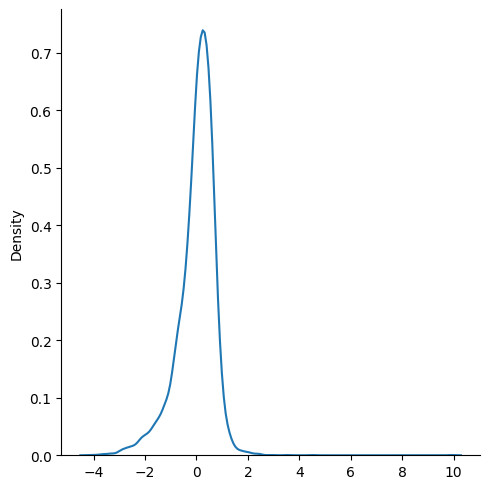

In [44]:
import seaborn as sns 
sns.displot(reg_pred-y_test,kind='kde')

In [45]:
from sklearn.metrics import r2_score


In [46]:
score=r2_score(reg_pred,y_test)
score

0.3395742960386745